# JaxQSOFit Tutorial: SDSS Example + Broad-Line Measurements

This notebook demonstrates the main features of `jaxqsofit` using a real SDSS spectrum near:

```python
coord = SkyCoord(184.0307, -2.2383, unit='deg')
```

Recommended fitting mode: `fit_method='optax+nuts'`.
This runs an SVI/optax warm start for initialization, then performs full posterior sampling with NUTS.

It covers:
- Fetching spectrum with `astroquery`
- Running fits (`nuts`, `optax`, `optax+nuts`)
- Overriding priors with `prior_config`
- Measuring broad-line FWHM and luminosity from fitted components


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from astroquery.sdss import SDSS
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.cosmology import FlatLambdaCDM

from jaxqsofit import QSOFit, build_default_prior_config


## 1. Download one SDSS spectrum


In [2]:
coord = SkyCoord(184.0307, -2.2383, unit='deg')
xid = SDSS.query_region(coord, spectro=True, radius=5 * u.arcsec)
sp = SDSS.get_spectra(matches=xid[:1])[0]

tb = sp[1].data
lam = np.asarray(10 ** tb['loglam'], dtype=float)
flux = np.asarray(tb['flux'], dtype=float)
ivar = np.asarray(tb['ivar'], dtype=float)

err = np.full_like(flux, 1e-6)
m = np.isfinite(ivar) & (ivar > 0)
err[m] = 1.0 / np.sqrt(ivar[m])

z = float(sp[2].data['z'][0])
ra = float(coord.ra.deg)
dec = float(coord.dec.deg)

print(f'Nspec pixels: {lam.size}')
print(f'z = {z:.5f}')


Nspec pixels: 3810
z = 0.10061


## 2. Build a default prior config (auto-scaled from flux)

You can use defaults directly, or modify selected entries.


In [3]:
prior_config = build_default_prior_config(flux)

# Example override: slightly tighter PL slope and Fe normalization priors
prior_config['PL_slope'] = {'loc': -1.5, 'scale': 0.3, 'low': -3.5, 'high': 0.5}
prior_config['log_Fe_uv_norm'] = {'loc': np.log(max(1e-3 * np.median(np.abs(flux)), 1e-10)), 'scale': 0.4}
prior_config['log_Fe_op_norm'] = {'loc': np.log(max(1e-3 * np.median(np.abs(flux)), 1e-10)), 'scale': 0.4}

# Robust line scale multipliers (optional)
prior_config['line_dmu_scale_mult'] = 0.25
prior_config['line_sig_scale_mult'] = 0.25
prior_config['line_amp_scale_mult'] = 0.20


## 3. Run a fit

Recommended:
- `fit_method='optax+nuts'` (SVI/optax initialization, then full NUTS posterior)

Other options:
- `fit_method='nuts'` (full posterior, slower initialization)
- `fit_method='optax'` (MAP only, fastest, no posterior samples)


sample: 100%|██████████| 100/100 [01:09<00:00,  1.44it/s, 255 steps of size 1.87e-02. acc. prob=0.98]


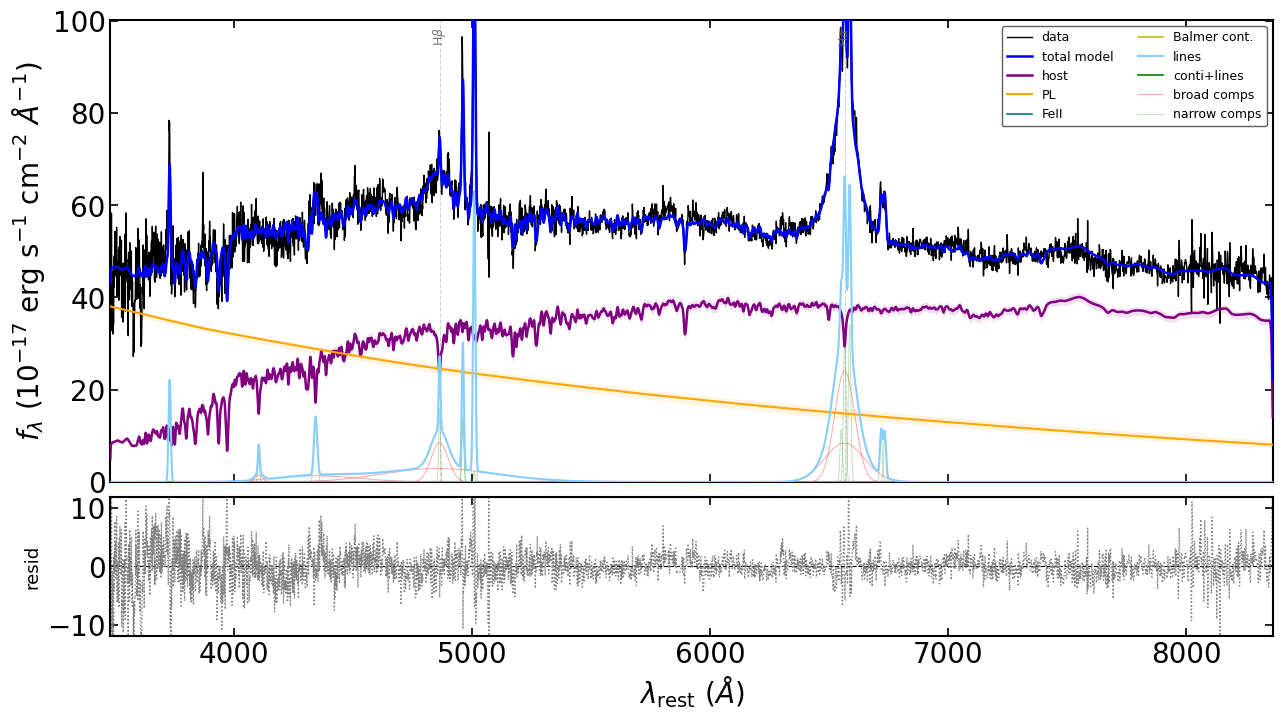

In [4]:
q = QSOFit(
    lam=lam,
    flux=flux,
    err=err,
    z=z,
    ra=ra,
    dec=dec,
    plateid=int(sp[0].header.get('plateid', 0)),
    mjd=int(sp[0].header.get('mjd', 0)),
    fiberid=int(sp[0].header.get('fiberid', 0)),
    path='.',
)

q.Fit(
    deredden=True,
    fit_method='optax+nuts',
    fit_lines=True,
    decompose_host=True,
    fit_fe=True,
    fit_bc=False,
    fit_poly=True,
    prior_config=prior_config,
    dsps_ssp_fn='../tempdata.h5',
    optax_steps=600,
    optax_lr=1e-2,
    nuts_warmup=50,
    nuts_samples=50,
    nuts_chains=1,
    plot_fig=True,
    save_fig=False,
    save_result=False,
)


## 4. MCMC diagnostics (trace + corner)


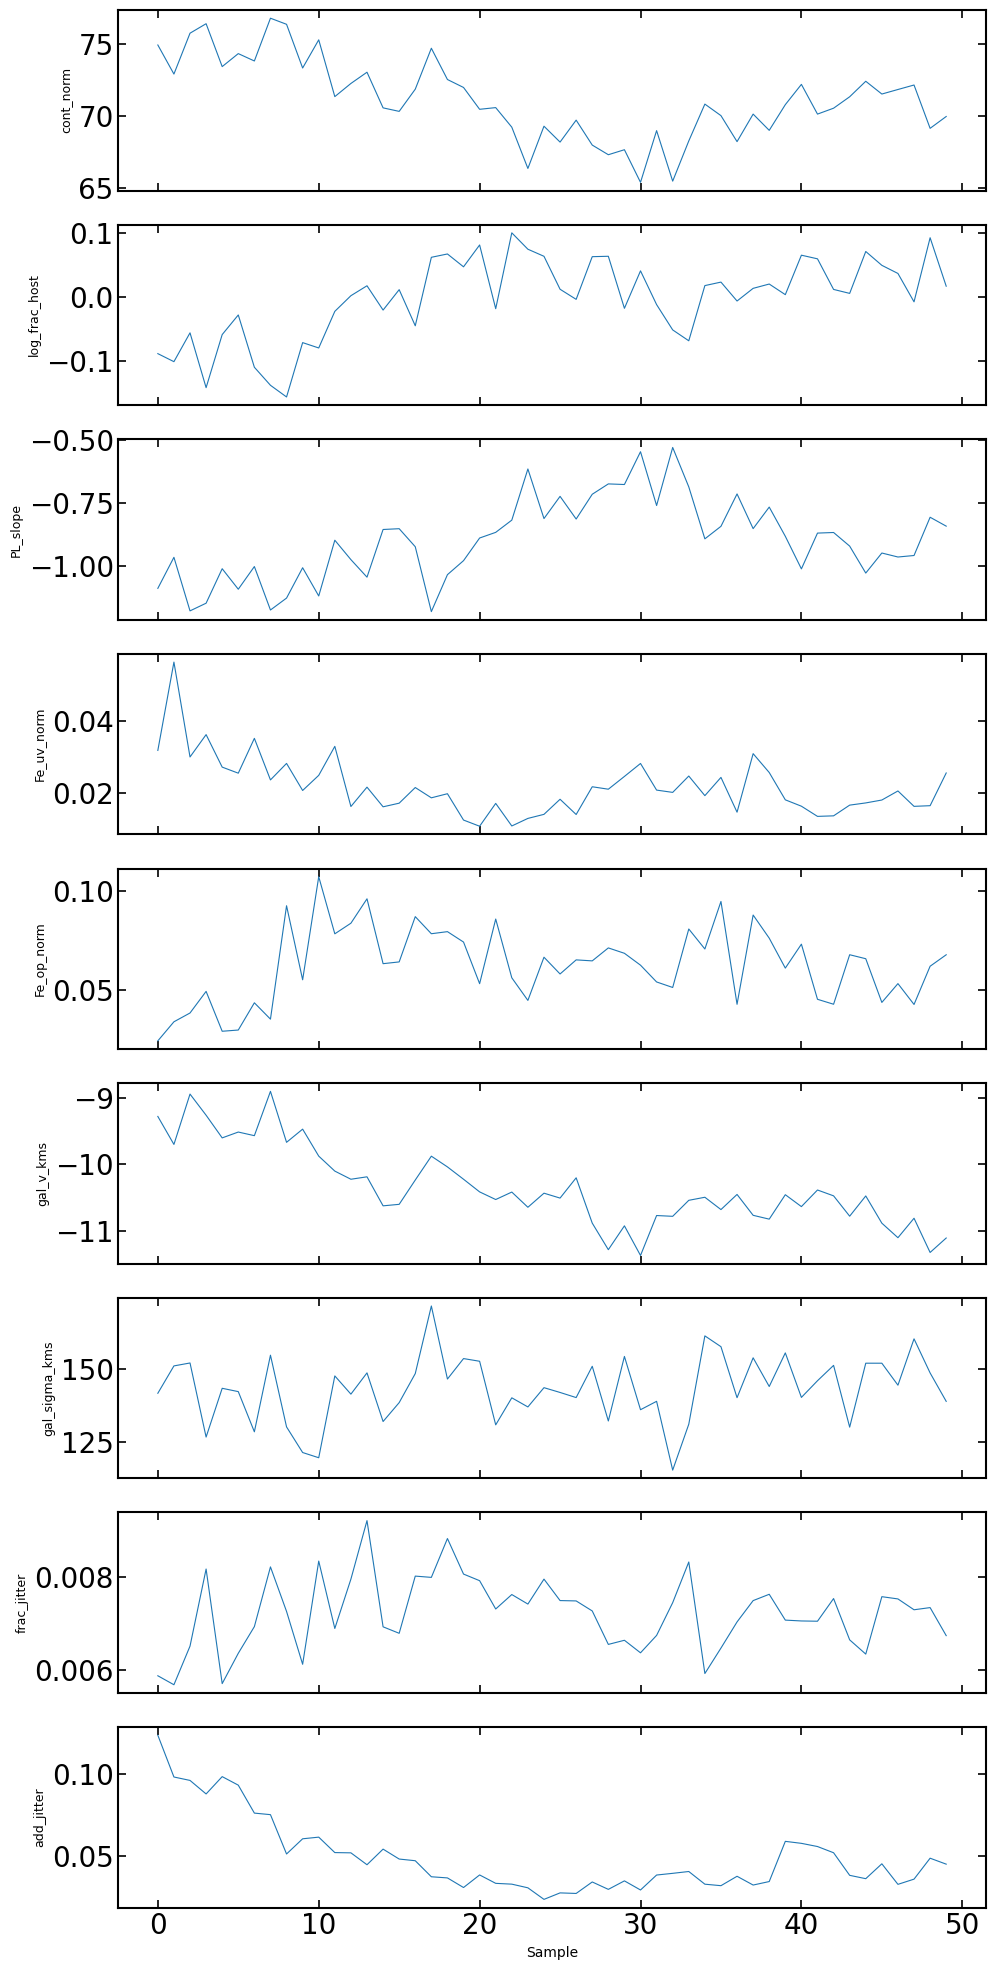

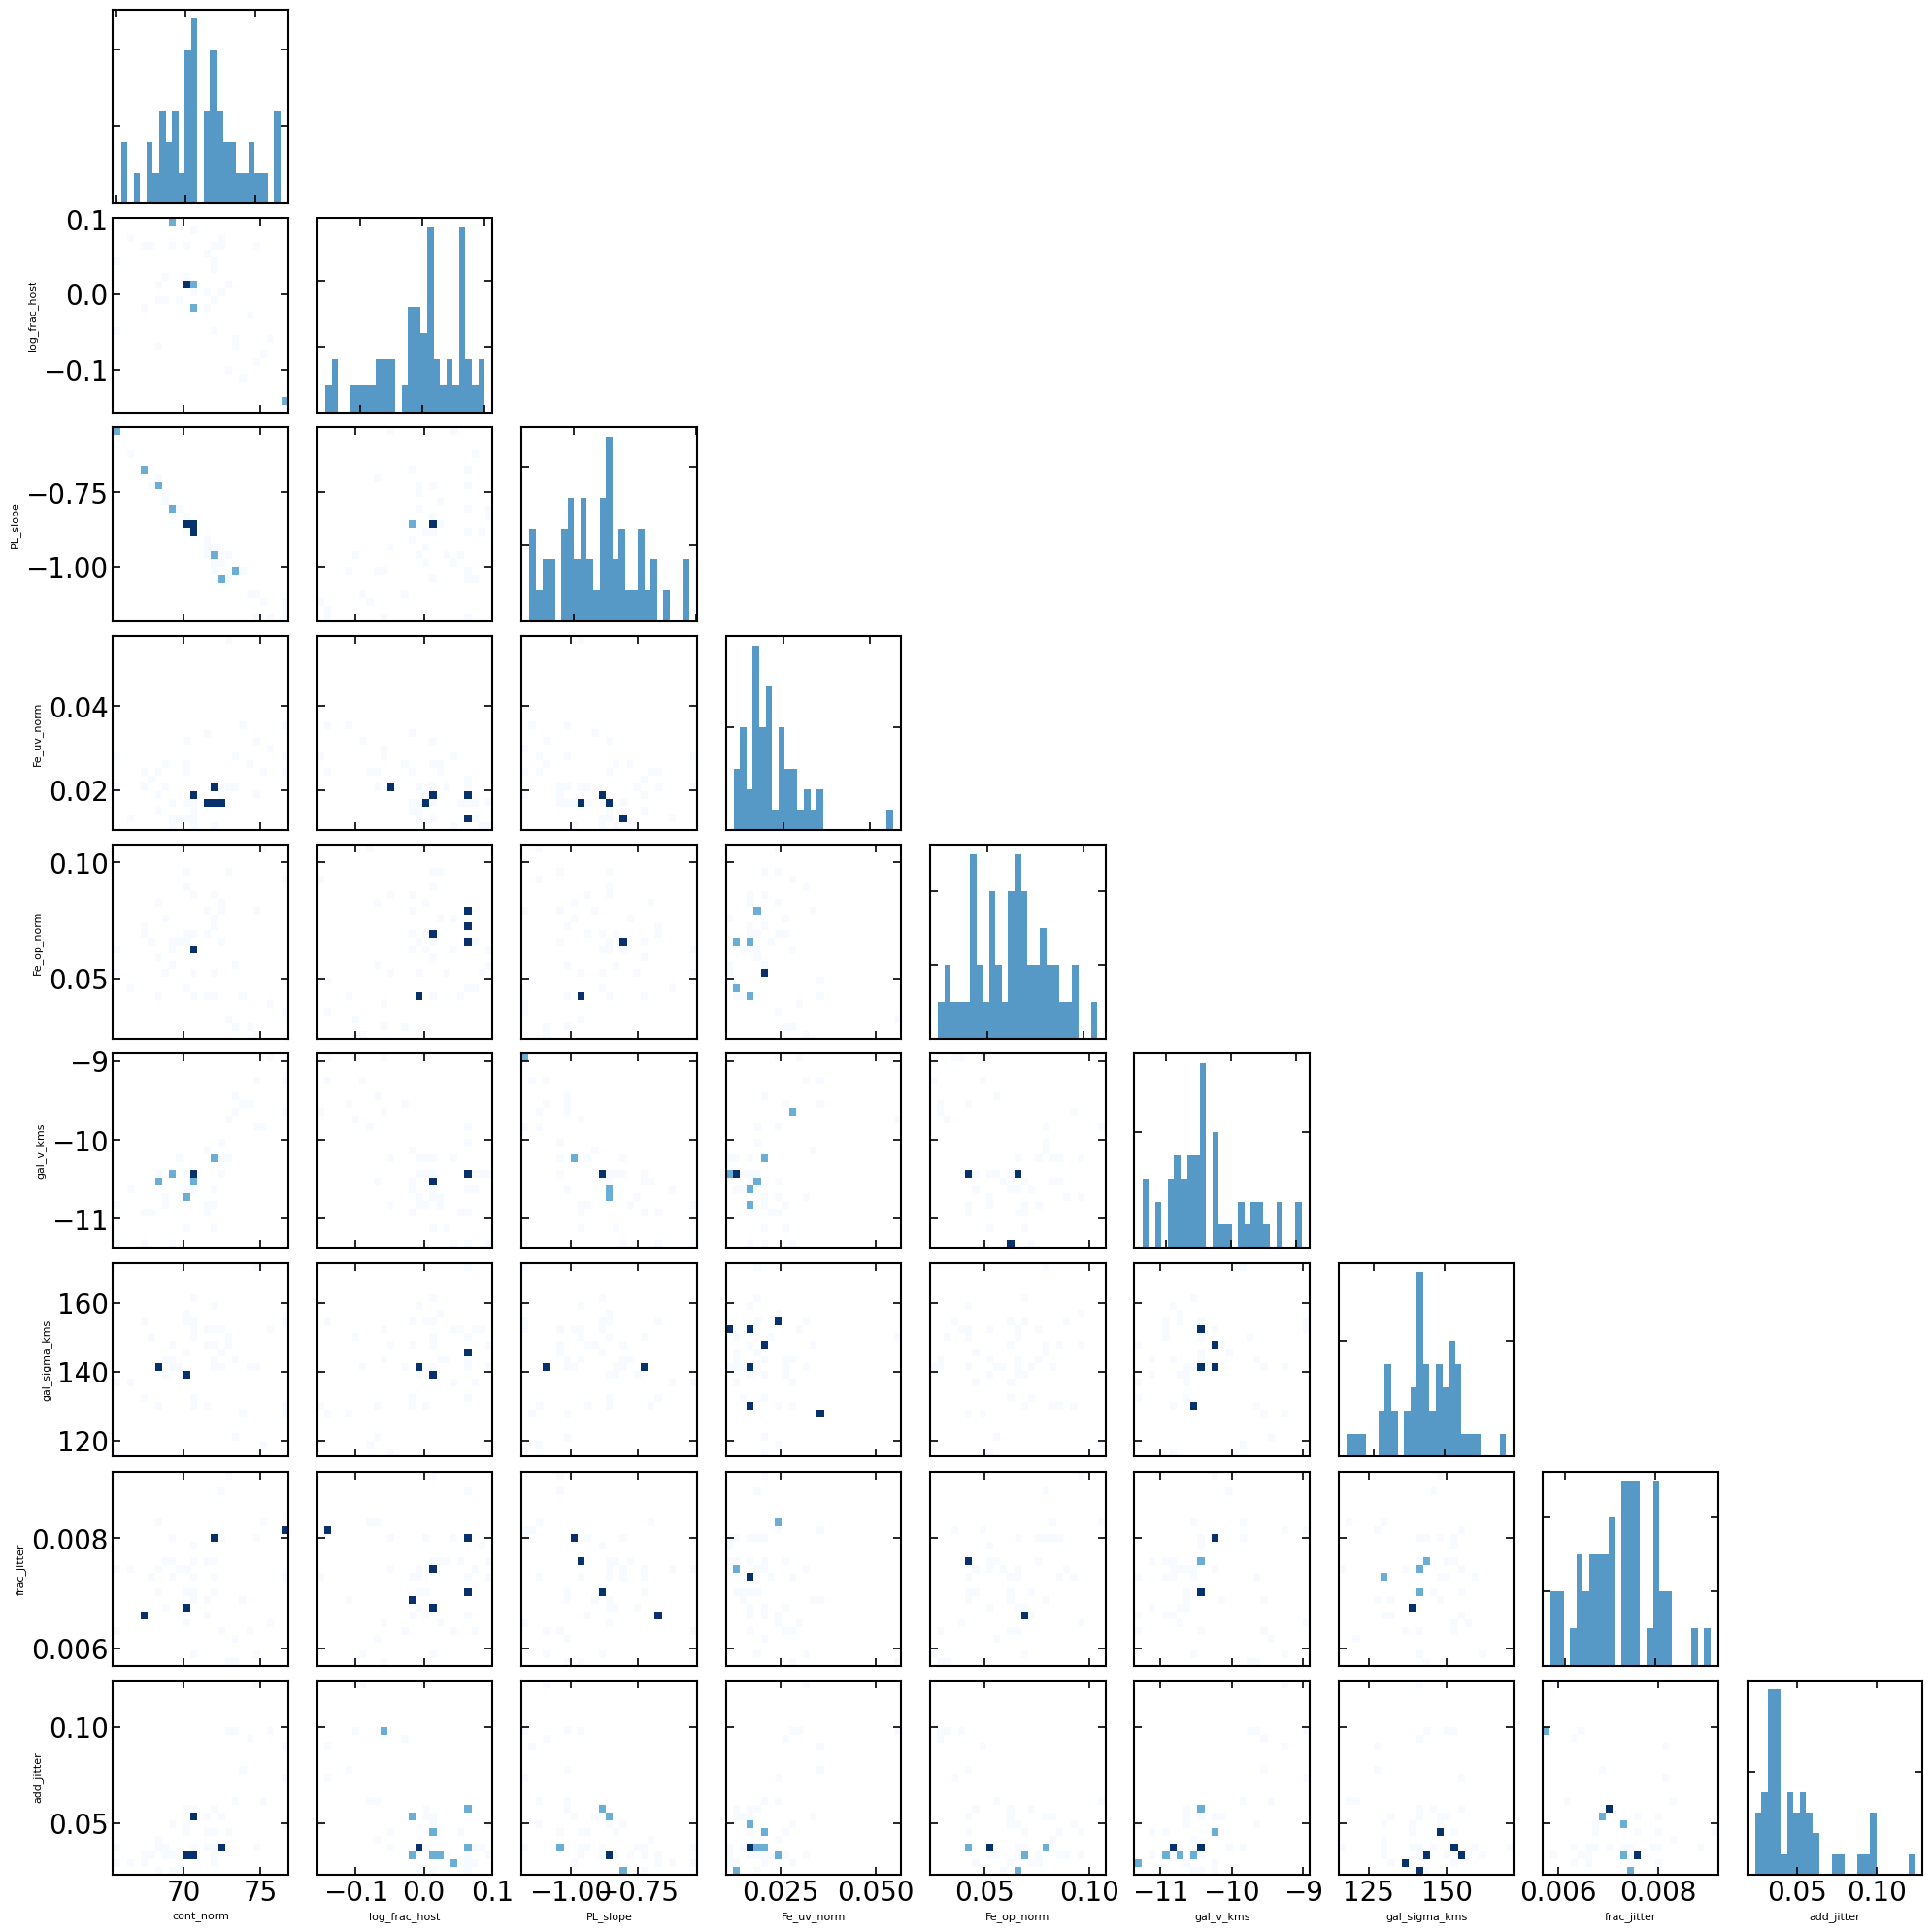

In [9]:
q.plot_mcmc_diagnostics(
    #param_names='all',
    do_trace=True,
    do_corner=True,
    max_vector_elems=2,
    corner_bins=25,
    corner_max_points=1500,
)


## 5. Measure broad-line FWHM and luminosity with posterior errors

`QSOFit` provides:
- `line_profile_from_components(line_key)` for posterior-median component profiles
- `line_profile_from_draw(draw_index, line_key)` for one posterior draw
- `line_props(profile, wave=None)` -> `(fwhm_kms, integrated_area)`

The integrated area is in `10^-17 erg s^-1 cm^-2` units, so convert to luminosity with cosmology.


In [10]:
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

def flux_to_luminosity(area_1e17, z):
    d_l_cm = cosmo.luminosity_distance(z).to(u.cm).value
    return area_1e17 * 1e-17 * 4.0 * np.pi * d_l_cm**2

amp_draws = np.asarray(q.pred_out['line_amp_per_component'])

for line_key in ["CIV_br", "MgII_br", "Hb_br", "Ha_br"]:
    fwhm_samp, logL_samp = [], []
    for i in range(amp_draws.shape[0]):
        prof = q.line_profile_from_draw(i, line_key)
        fwhm, area = q.line_props(prof)
        fwhm_samp.append(fwhm)
        if np.isfinite(area) and area > 0:
            logL_samp.append(np.log10(flux_to_luminosity(area, q.z)))
        else:
            logL_samp.append(np.nan)

    fwhm_samp = np.asarray(fwhm_samp, dtype=float)
    logL_samp = np.asarray(logL_samp, dtype=float)

    f16, f50, f84 = np.nanpercentile(fwhm_samp, [16, 50, 84])
    l16, l50, l84 = np.nanpercentile(logL_samp, [16, 50, 84])

    print(
        f"{line_key:8s}  "
        f"FWHM={f50:.1f} (+{f84-f50:.1f}/-{f50-f16:.1f}) km/s   "
        f"logL={l50:.3f} (+{l84-l50:.3f}/-{l50-l16:.3f})"
    )


CIV_br    FWHM =      nan km/s   area =        nan   logL =     nan
MgII_br   FWHM =      nan km/s   area =        nan   logL =     nan
Hb_br     FWHM =   6489.0 km/s   area =   2363.478   logL =  41.783
Ha_br     FWHM =   5178.0 km/s   area =   5174.161   logL =  42.123


## 6. Inspect posterior samples (recommended with `optax+nuts`)

If you used `fit_method='nuts'` or `'optax+nuts'`, posterior samples are stored in:
- `q.numpyro_samples`


In [11]:
if hasattr(q, 'numpyro_samples') and q.numpyro_samples is not None:
    keys = sorted(q.numpyro_samples.keys())
    print('Num posterior params:', len(keys))
    print('First 20 keys:', keys[:20])
else:
    print('No NumPyro samples available (likely fit_method=optax).')


Num posterior params: 39
First 20 keys: ['Fe_op_FWHM', 'Fe_op_norm', 'Fe_op_shift', 'Fe_uv_FWHM', 'Fe_uv_norm', 'Fe_uv_shift', 'PL_norm_eff', 'PL_slope', 'add_jitter', 'agn_model', 'cont_norm', 'continuum_model', 'f_bc_model', 'f_fe_balmer_model', 'f_fe_mgii_model', 'f_pl_model', 'f_poly_model', 'frac_host', 'frac_jitter', 'fsps_weights']


## 7. Quick component diagnostics


In [12]:
print('max data        :', np.nanmax(q.flux))
print('max total model :', np.nanmax(q.model_total))
print('max PL          :', np.nanmax(q.f_pl_model))
print('max host        :', np.nanmax(q.host))
print('max FeII        :', np.nanmax(q.f_fe_mgii_model + q.f_fe_balmer_model))
print('max Balmer cont :', np.nanmax(q.f_bc_model))
print('max lines       :', np.nanmax(q.f_line_model))


max data        : 159.85346122995483
max total model : 117.70686971608836
max PL          : 38.057290681115205
max host        : 40.11254684795894
max FeII        : 0.06249440237638176
max Balmer cont : 0.0
max lines       : 66.20218685265684
